## Configuración inicial del entorno

In [1]:
%pip install torchvision matplotlib pandas scikit-learn seaborn
%pip install "numpy<2"


[notice] A new release of pip available: 22.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip available: 22.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import sys

print(sys.executable)

/Users/user/Documents/GitHub/AI_Agents/.venv/bin/python


In [3]:
!pip -V

pip 22.3 from /Users/user/Documents/GitHub/AI_Agents/.venv/lib/python3.11/site-packages/pip (python 3.11)


In [4]:
%pip list

Package                   Version
------------------------- -----------
aiohappyeyeballs          2.6.2
aiohttp                   3.14.1
aiosignal                 1.4.0
annotated-doc             0.0.4
annotated-types           0.7.0
anthropic                 0.109.2
anyio                     4.13.0
appnope                   0.1.4
argon2-cffi               25.1.0
argon2-cffi-bindings      25.1.0
arrow                     1.4.0
asttokens                 3.0.1
async-lru                 2.3.0
attrs                     26.1.0
babel                     2.18.0
beautifulsoup4            4.15.0
bleach                    6.4.0
certifi                   2026.5.20
cffi                      2.0.0
charset-normalizer        3.4.7
click                     8.4.1
comm                      0.2.3
contourpy                 1.3.3
cryptography              49.0.0
cycler                    0.12.1
debugpy                   1.8.21
decorator                 5.3.1
defusedxml                0.7.1
distro          

In [5]:
import torch
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Configuración visual de las gráficas
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12

print(f"PyTorch Version: {torch.__version__}")
print(f"Torchvision Version: {torchvision.__version__}")

PyTorch Version: 2.2.2
Torchvision Version: 0.17.2


## Carga de datos

In [ ]:
import os
import shutil
import ssl
import torch
import torchvision
from torchvision import transforms
from torch.utils.data import random_split

# 1. Eliminar datos existentes previamente
data_dir = '../data'
if os.path.exists(data_dir):
    shutil.rmtree(data_dir)
    print("Carpeta '../data' eliminada correctamente.")

# Desactivar la verificación SSL para macOS
ssl._create_default_https_context = ssl._create_unverified_context

raw_transform = transforms.Compose([
    transforms.ToTensor()
])

# 2. Descargar datasets base
full_train_dataset = torchvision.datasets.MNIST(
    root=data_dir, 
    train=True, 
    download=True, 
    transform=raw_transform
)

test_dataset = torchvision.datasets.MNIST(
    root=data_dir, 
    train=False, 
    download=True, 
    transform=raw_transform
)

# 3. Dividir el conjunto de entrenamiento (60,000 imágenes) en Train (80%) y Validation (20%)
train_size = int(0.8 * len(full_train_dataset))  # 48,000 imágenes
val_size = len(full_train_dataset) - train_size   # 12,000 imágenes

# Generador con semilla fijada para reproducibilidad
generator = torch.Generator().manual_seed(42)

train_dataset, val_dataset = random_split(
    full_train_dataset, 
    [train_size, val_size], 
    generator=generator
)

# 4. Confirmar distribución de datos
print(f"Imágenes de entrenamiento (80%): {len(train_dataset)}")
print(f"Imágenes de validación (20%):    {len(val_dataset)}")
print(f"Imágenes de prueba (Test):        {len(test_dataset)}")

Carpeta '../data' eliminada correctamente.
Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9912422/9912422 [00:01<00:00, 5323706.72it/s]


Extracting ../data/MNIST/raw/train-images-idx3-ubyte.gz to ../data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28881/28881 [00:00<00:00, 360912.81it/s]


Extracting ../data/MNIST/raw/train-labels-idx1-ubyte.gz to ../data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1648877/1648877 [00:00<00:00, 2069989.68it/s]


Extracting ../data/MNIST/raw/t10k-images-idx3-ubyte.gz to ../data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4542/4542 [00:00<00:00, 4237217.25it/s]

Extracting ../data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ../data/MNIST/raw

Imágenes de entrenamiento (80%): 48000
Imágenes de validación (20%):    12000
Imágenes de prueba (Test):        10000


In [7]:
# Tomar una muestra
image, label = train_dataset[0]

print(f"Forma del Tensor de imagen (C x H x W): {image.shape}")
print(f"Tipo de datos (dtype): {image.dtype}")
print(f"Valor mínimo de píxel: {image.min():.4f}")
print(f"Valor máximo de píxel: {image.max():.4f}")
print(f"Etiqueta (label) de ejemplo: {label}")

Forma del Tensor de imagen (C x H x W): torch.Size([1, 28, 28])
Tipo de datos (dtype): torch.float32
Valor mínimo de píxel: 0.0000
Valor máximo de píxel: 1.0000
Etiqueta (label) de ejemplo: 6


Forma del Tensor de imagen (C x H x W): torch.Size([1, 28, 28])
Tipo de datos (dtype): torch.float32
Valor mínimo de píxel: 0.0000
Valor máximo de píxel: 1.0000
Etiqueta (label) de ejemplo: 6


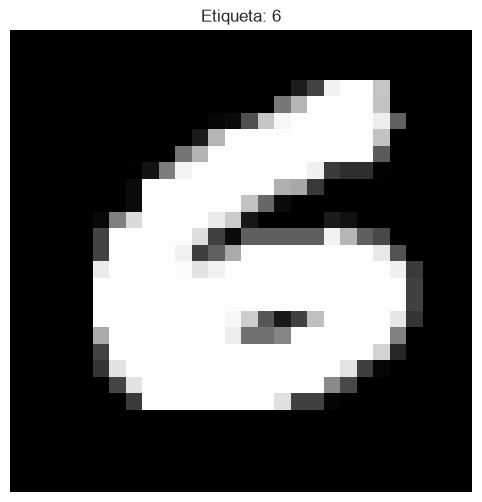

In [8]:
# Tomar una muestra
image, label = train_dataset[0]

print(f"Forma del Tensor de imagen (C x H x W): {image.shape}")
print(f"Tipo de datos (dtype): {image.dtype}")
print(f"Valor mínimo de píxel: {image.min():.4f}")
print(f"Valor máximo de píxel: {image.max():.4f}")
print(f"Etiqueta (label) de ejemplo: {label}")

# Visualizar la imagen
# image.squeeze(0) remueve el canal único de (1, 28, 28) dejándolo en (28, 28)
plt.imshow(image.squeeze(0), cmap='gray')
plt.title(f"Etiqueta: {label}")
plt.axis('off')  # Oculta los ejes con los números de píxeles
plt.show()

## Análisis exploratorio de los datos

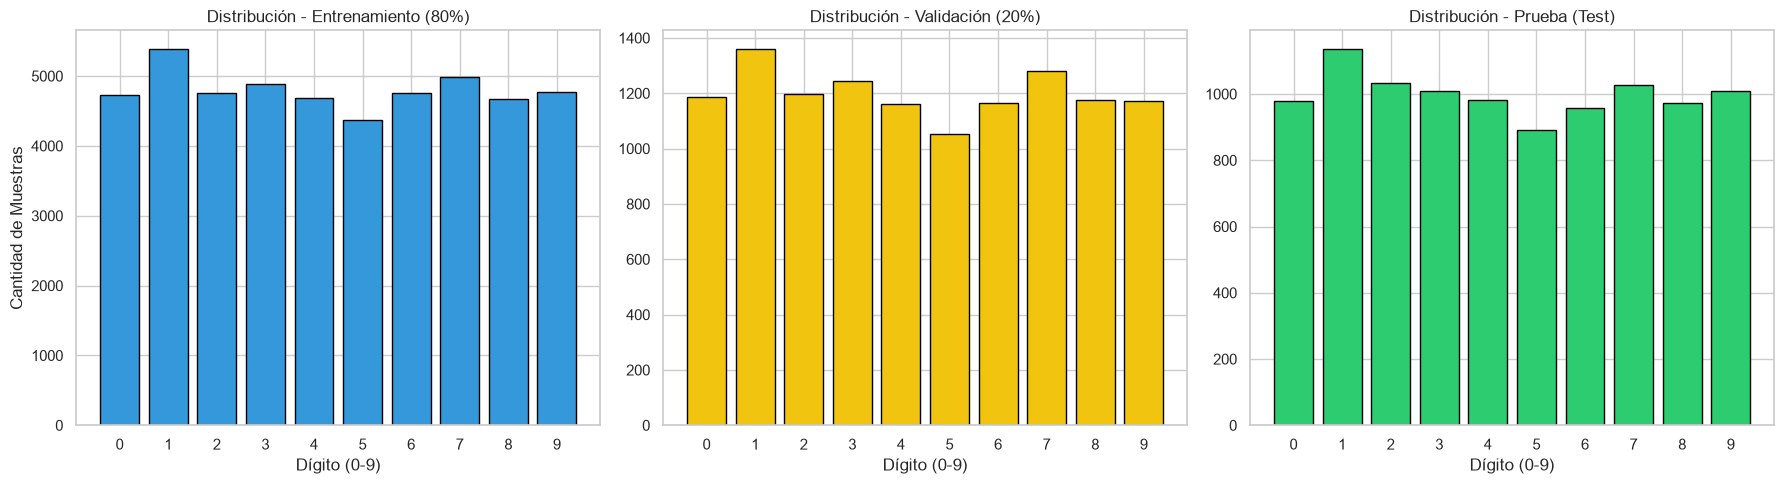

Dígito   | Train (%)  | Val (%)    | Test (%)  
---------------------------------------------
0        | 9.86       | 9.90       | 9.80      
1        | 11.21      | 11.33      | 11.35     
2        | 9.92       | 9.97       | 10.32     
3        | 10.18      | 10.38      | 10.10     
4        | 9.75       | 9.68       | 9.82      
5        | 9.10       | 8.77       | 8.92      
6        | 9.90       | 9.72       | 9.58      
7        | 10.38      | 10.68      | 10.28     
8        | 9.74       | 9.81       | 9.74      
9        | 9.95       | 9.78       | 10.09     


In [9]:
# Extraer etiquetas de forma eficiente sin cargar las imágenes a memoria
targets_array = full_train_dataset.targets.numpy()

train_labels = targets_array[train_dataset.indices]
val_labels = targets_array[val_dataset.indices]
test_labels = test_dataset.targets.numpy()

# Contar frecuencias
train_counts = Counter(train_labels)
val_counts = Counter(val_labels)
test_counts = Counter(test_labels)

# Visualización gráfica de la distribución en los 3 conjuntos
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Entrenamiento
axes[0].bar(train_counts.keys(), train_counts.values(), color='#3498db', edgecolor='black')
axes[0].set_title("Distribución - Entrenamiento (80%)")
axes[0].set_xlabel("Dígito (0-9)")
axes[0].set_ylabel("Cantidad de Muestras")
axes[0].set_xticks(range(10))

# Validación
axes[1].bar(val_counts.keys(), val_counts.values(), color='#f1c40f', edgecolor='black')
axes[1].set_title("Distribución - Validación (20%)")
axes[1].set_xlabel("Dígito (0-9)")
axes[1].set_xticks(range(10))

# Test
axes[2].bar(test_counts.keys(), test_counts.values(), color='#2ecc71', edgecolor='black')
axes[2].set_title("Distribución - Prueba (Test)")
axes[2].set_xlabel("Dígito (0-9)")
axes[2].set_xticks(range(10))

plt.tight_layout()
plt.show()

# Imprimir proporciones comparativas
print(f"{'Dígito':<8} | {'Train (%)':<10} | {'Val (%)':<10} | {'Test (%)':<10}")
print("-" * 45)
for digit in range(10):
    p_train = (train_counts[digit] / len(train_dataset)) * 100
    p_val = (val_counts[digit] / len(val_dataset)) * 100
    p_test = (test_counts[digit] / len(test_dataset)) * 100
    print(f"{digit:<8} | {p_train:<10.2f} | {p_val:<10.2f} | {p_test:<10.2f}")

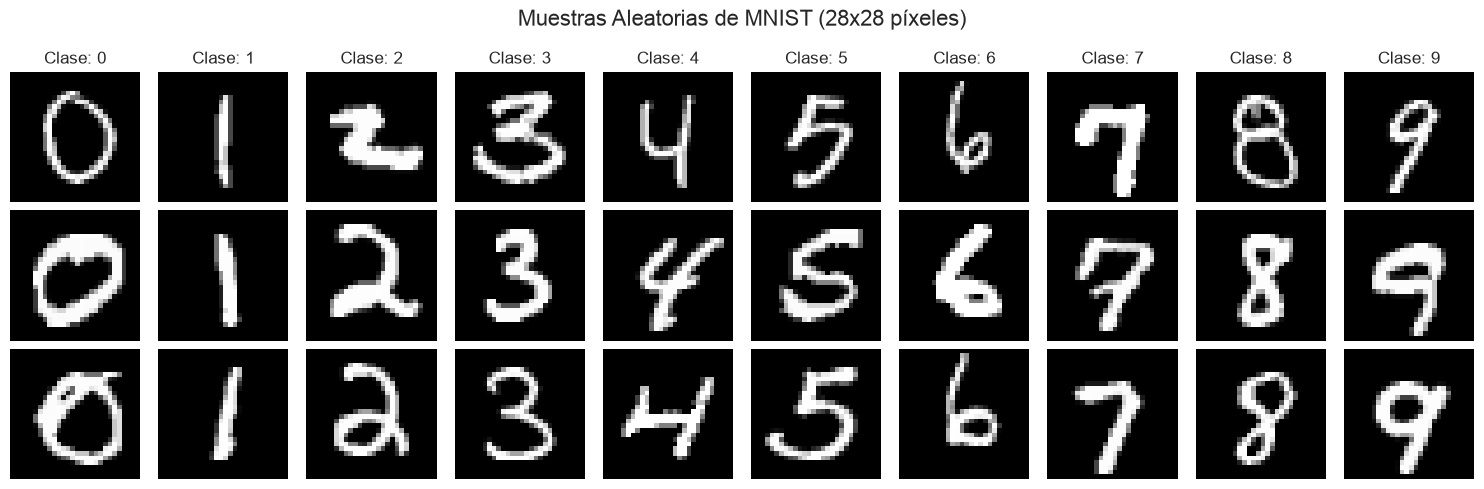

In [10]:
fig, axes = plt.subplots(3, 10, figsize=(15, 5))
fig.suptitle("Muestras Aleatorias de MNIST (28x28 píxeles)", fontsize=16)

for digit in range(10):
    # Obtener índices de todas las imágenes pertenecientes al dígito actual
    indices = [i for i, l in enumerate(train_labels) if l == digit]
    # Seleccionar 3 aleatorias
    selected_indices = np.random.choice(indices, 3, replace=False)
    
    for row, idx in enumerate(selected_indices):
        img, _ = train_dataset[idx]
        ax = axes[row, digit]
        # Convertir Tensor (1, 28, 28) a matriz 2D (28, 28)
        ax.imshow(img.squeeze().numpy(), cmap='gray')
        ax.axis('off')
        if row == 0:
            ax.set_title(f"Clase: {digit}")

plt.tight_layout()
plt.show()

In [11]:
# Apilar todas las imágenes en un solo tensor: (60000, 1, 28, 28)
full_train_tensors = torch.stack([img for img, _ in train_dataset])

mean = full_train_tensors.mean().item()
std = full_train_tensors.std().item()

print("📊 Métricas de Normalización para PyTorch Transforms:")
print(f"Media (Mean): {mean:.4f}")
print(f"Desviación Estándar (Std): {std:.4f}")
print(f"\nUso en tu código futuro:")
print(f"transforms.Normalize(({mean:.4f},), ({std:.4f},))")

📊 Métricas de Normalización para PyTorch Transforms:
Media (Mean): 0.1307
Desviación Estándar (Std): 0.3082

Uso en tu código futuro:
transforms.Normalize((0.1307,), (0.3082,))


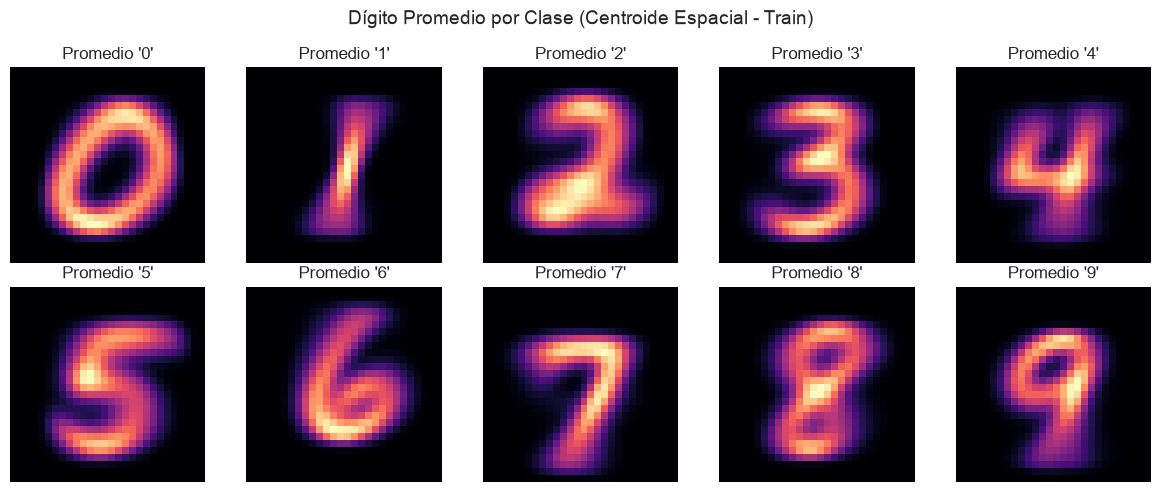

In [12]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle("Dígito Promedio por Clase (Centroide Espacial - Train)", fontsize=14)

# Accedemos directamente al tensor de datos original (60000, 28, 28)
# Lo convertimos a float y normalizamos a [0.0, 1.0]
all_train_data = full_train_dataset.data[train_dataset.indices].float() / 255.0

for digit in range(10):
    # Filtramos las imágenes que corresponden al dígito actual usando PyTorch
    mask = (train_labels == digit)
    digit_images = all_train_data[mask]
    
    # Calculamos la imagen promedio a lo largo del eje 0
    mean_image = digit_images.mean(dim=0).numpy()
    
    # Dibujamos en la cuadrícula
    ax = axes[digit // 5, digit % 5]
    im = ax.imshow(mean_image, cmap='magma')
    ax.set_title(f"Promedio '{digit}'")
    ax.axis('off')

plt.tight_layout()
plt.show()

In [13]:
# Analizar la intensidad de píxeles promedio
sample_img, _ = train_dataset[0]
bg_pixel_val = sample_img[0, 0, 0].item() # Esquina superior izquierda

print("🔍 DIAGNÓSTICO DE FORMATO:")
print(f"- Fondo en MNIST: Valor ~{bg_pixel_val:.1f} ({'Negro' if bg_pixel_val == 0 else 'Blanco'})")
print(f"- Trazo en MNIST: Valor ~1.0 (Blanco)")
print("\n⚠️ DESAFÍO TÉCNICO PARA EL FRONTEND CANVAS:")
print("HTML5 Canvas por defecto dibuja trazos negros sobre fondo blanco.")
print("Si enviamos la imagen del Canvas directamente a la CNN, la predicción fallará completamente.")
print("Solución requerida en el pipeline: Inversión de colores (Invert), centrado por masa y redimensión a 28x28.")

🔍 DIAGNÓSTICO DE FORMATO:
- Fondo en MNIST: Valor ~0.0 (Negro)
- Trazo en MNIST: Valor ~1.0 (Blanco)

⚠️ DESAFÍO TÉCNICO PARA EL FRONTEND CANVAS:
HTML5 Canvas por defecto dibuja trazos negros sobre fondo blanco.
Si enviamos la imagen del Canvas directamente a la CNN, la predicción fallará completamente.
Solución requerida en el pipeline: Inversión de colores (Invert), centrado por masa y redimensión a 28x28.
